In [ ]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-05-03 13:13:53--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.1’

names.txt.1         100%[===================>] 222.80K  --.-KB/s    in 0.01s   

2026-05-03 13:13:54 (16.1 MB/s) - ‘names.txt.1’ saved [228145/228145]



In [ ]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [ ]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [39]:
from sklearn.manifold import TSNE

In [ ]:
random.seed(42)
torch.manual_seed(42)

In [ ]:
ctx_len = 4
X, Y = [], []

random.shuffle(words)

for w in words:
  w = '.' * ctx_len + w + '.'
  # ....0123
  for i in range(len(w) - ctx_len):
    x = [stoi[c] for c in w[i:i+ctx_len]]
    y = stoi[w[i+ctx_len]]
    X.append(x)
    Y.append(y)

n_train = int(0.8*len(X))
n_dev = int(0.1*len(X))

X_train, Y_train = X[:n_train], Y[:n_train]
X_dev, Y_dev = X[n_train:n_train+n_dev], Y[n_train:n_train+n_dev]
X_test, Y_test = X[n_train+n_dev:], Y[n_train+n_dev:]
print(len(X_train), len(X_dev), len(X_test))

182516 22814 22816


In [ ]:
emb_dim = 10
layer1_size = 200

# Embedding Table
emb = torch.randn(vocab_size, emb_dim, requires_grad=True)  # (27, 10)

# Layer 1
W1 = torch.randn(ctx_len * emb_dim, layer1_size, requires_grad=True)  # (10*4, 200)
b1 = torch.zeros(layer1_size, requires_grad=True)

# Layer 2
W2 = torch.randn(layer1_size, vocab_size, requires_grad=True)  # (200, 27)
b2 = torch.zeros(vocab_size, requires_grad=True)

params = [emb, W1, b1, W2, b2]

In [ ]:
def fwd(x):
  # x = (batch_size, ctx_len)
  # 1. Embedding table lookup
  h = emb[x]  # (batch_size, ctx_len, emb_dim)
  # 2. First layer
  h = h.view(-1, ctx_len * emb_dim) @ W1 + b1  # (batch_size, layer1_size)
  h = torch.tanh(h)
  # 3. Final layer
  logits = h @ W2 + b2  # (batch_size, vocab_size)
  # F.CrossEntropyLoss takes the logits as inputs
  # prob = torch.softmax(logits, dim=1)
  return logits

In [ ]:
fwd(torch.tensor(X_train))

tensor([[ 10.2965,  -3.5006, -13.4919,  ...,   5.4685,   4.1101,  -3.5186],
        [ -0.2080,  -7.8398,   2.7401,  ...,  11.9525,  -9.2016, -13.4814],
        [  4.6200,  -5.2179,  -0.3790,  ...,  -3.8812,  -3.6709, -20.2308],
        ...,
        [ -8.3038,  21.3037,   0.6461,  ...,   0.2123,  13.2140,   2.8620],
        [ 10.2965,  -3.5006, -13.4919,  ...,   5.4685,   4.1101,  -3.5186],
        [-12.6493, -17.1941,  -1.2137,  ...,   3.4325, -22.4076,  -7.4599]],
       grad_fn=<AddBackward0>)

In [ ]:
i = 0
stepi = []
lossi = []

In [ ]:
epochs = 100
bsz = 32

for e in range(epochs):
  for step in range(len(X_train)//bsz):
    X_input = torch.tensor(X_train[step*bsz:(step+1)*bsz])
    Y_target = torch.tensor(Y_train[step*bsz:(step+1)*bsz])

    for p in params:
      p.grad = None

    X_pred = fwd(X_input)

    loss = F.cross_entropy(input=X_pred, target=Y_target)

    loss.backward()

    lr = 0.1 if e < 50 else 0.01
    for p in params:
      p.data += -lr * p.grad

    stepi.append(i)
    i += 1
    lossi.append(loss.item())

  print(loss.item())


2.406921148300171
2.3689098358154297
2.314141273498535
2.2927589416503906
2.31168794631958
2.3292930126190186
2.3298561573028564
2.317323923110962
2.293466806411743
2.2731802463531494
2.260122299194336
2.253702163696289
2.2468619346618652
2.240853786468506
2.2360401153564453
2.2320306301116943
2.2257072925567627
2.217958927154541
2.2103512287139893
2.2037479877471924
2.198225736618042
2.19502592086792
2.192728042602539
2.1883621215820312
2.182983875274658
2.1787705421447754
2.177459239959717
2.1763994693756104
2.174699306488037
2.1723170280456543
2.1696419715881348
2.1695363521575928
2.166513442993164
2.161384344100952
2.154731512069702
2.1468918323516846
2.137939453125
2.129039764404297
2.1243581771850586
2.12190318107605
2.1207327842712402
2.1212873458862305
2.121656656265259
2.116827964782715
2.1095802783966064
2.106266498565674
2.103161334991455
2.100996971130371
2.1014404296875
2.09580135345459
2.0175654888153076
2.02553391456604
2.026762008666992
2.0263607501983643
2.025476932525

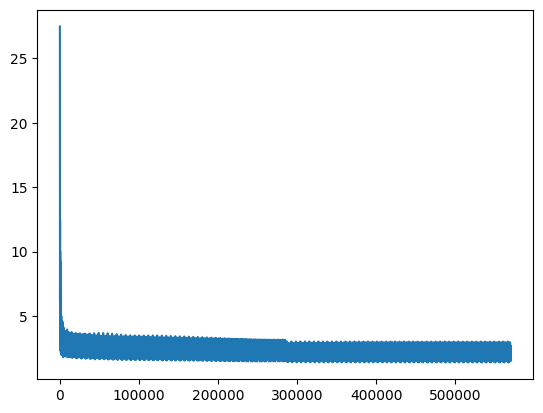

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
F.cross_entropy(input=fwd(X_train), target=torch.tensor(Y_train)).item()

2.066380739212036

In [ ]:
F.cross_entropy(input=fwd(X_dev), target=torch.tensor(Y_dev)).item()

2.143977642059326

In [ ]:
F.cross_entropy(input=fwd(X_test), target=torch.tensor(Y_test)).item()

2.130765676498413

In [ ]:
cnt = 20
for _ in range(cnt):
  out_str = ""
  inp = '.' * (ctx_len - min(ctx_len, len(out_str))) + out_str
  while True:
    x = [stoi[c] for c in inp[-ctx_len:]]
    logits = fwd(x)
    probs = F.softmax(logits, dim=1)

    idx = torch.multinomial(probs, num_samples=1).item()
    char = itos[idx]

    if char == '.':
      break

    inp += char
    out_str += char

  print(out_str)

elayda
dhadgis
rene
nihani
corvy
bledosean
agdulsarnen
aaeryn
kond
nelo
jahne
kinukan
riya
shay
kenni
ezily
mifen
boku
adber
cordar


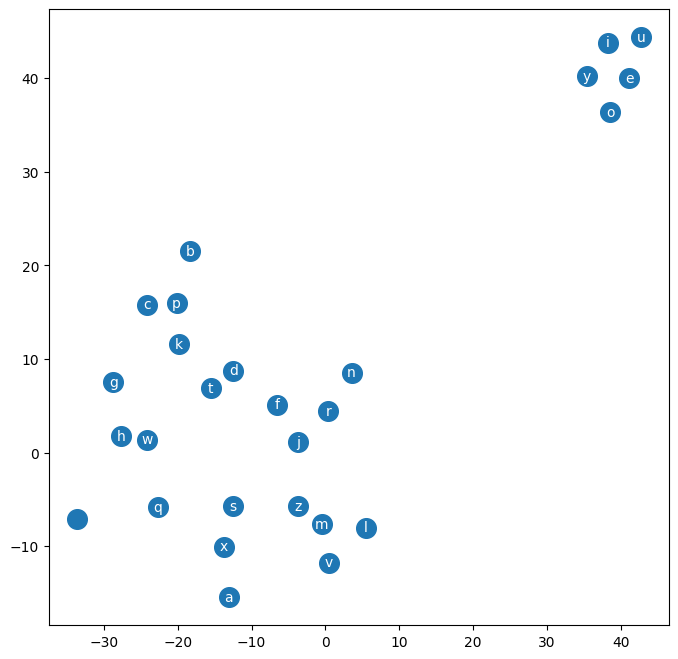

In [38]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
emb_2d = tsne.fit_transform(emb.data.numpy())

plt.figure(figsize=(8,8))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=200)
for i in range(1, vocab_size):
    plt.text(emb_2d[i,0], emb_2d[i,1], itos[i], ha='center', va='center', color='white')